# Classificação de Crises Epilépticas via EEG
## Projeto de Otimização Não Linear — Regressão Logística + Gradiente Descendente

**Integrantes:** Bruno Marques Rodrigues, Gabrielly Silva Batista, Josué Caleb Avelino dos Santos, Vitória Emanuele de Sousa Silva.

Este notebook implementa, de forma comentada, um problema de **otimização não linear sem restrições** aplicado ao **aprendizado supervisionado**, mais especificamente uma **classificação binária** de sinais de EEG em duas classes:

- **Classe 1:** crise epiléptica
- **Classe 0:** ausência de crise

A ideia central é modelar a tarefa por meio da **Regressão Logística**, cuja função objetivo é a **Entropia Cruzada (Log-Loss)**. O treinamento será feito com **Gradiente Descendente**, destacando o aspecto de otimização do projeto.

## 0. Objetivos do notebook

Neste notebook, vamos:

1. carregar o conjunto de dados;
2. inspecionar o formato dos sinais de EEG;
3. pré-processar os dados;
4. formular o problema matematicamente;
5. implementar a Regressão Logística **do zero**;
6. treinar o modelo via **Gradiente Descendente**;
7. avaliar os resultados;
8. comparar, opcionalmente, com a implementação do `scikit-learn`.

> **Observação importante:** o foco principal do projeto não é apenas classificar bem, mas mostrar claramente a **formulação de otimização**, o cálculo do gradiente, o processo iterativo e os resultados obtidos.

## 1. Bibliotecas
Se alguma biblioteca não estiver instalada, rode no terminal do VS Code:

```bash
pip install numpy matplotlib scikit-learn jupyter
```

In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    roc_curve,
    recall_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)

## 2. Definir o caminho do dataset

Altere a variável `path_base` para a pasta onde estão os arquivos:

- `eeg-seizure_train.npz`
- `eeg-seizure_test.npz`

In [2]:
path = kagglehub.dataset_download("adibadea/chbmitseizuredataset")

print("Dataset baixado em:", path)
print("Arquivos:", os.listdir(path))

Dataset baixado em: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Arquivos: ['eeg-seizure_train.npz', 'eeg-predictive_train.npz', 'eeg-seizure_test.npz', 'eeg-predictive_val_balanced.npz', 'eeg-predictive_val.npz', 'eeg-seizure_val_balanced.npz', 'eeg-seizure_val.npz']


## 3. Verificar os arquivos e carregar os dados

Esperamos encontrar, na pasta do dataset, os arquivos:

- `eeg-seizure_train.npz`
- `eeg-seizure_test.npz`

A célula abaixo carrega os dados e mostra seus formatos.

In [3]:
# Baixar/obter o caminho do dataset
path = kagglehub.dataset_download("adibadea/chbmitseizuredataset")
print("Dataset baixado em:", path)

# Verificar a estrutura da pasta
arquivos = os.listdir(path)
print("Conteúdo da pasta:", arquivos)

# Definir automaticamente o caminho base correto
if "eeg-seizure_train.npz" in arquivos and "eeg-seizure_test.npz" in arquivos:
    path_base = path
elif "dataset" in arquivos:
    path_base = os.path.join(path, "dataset")
else:
    raise FileNotFoundError(
        f"Não encontrei os arquivos esperados em {path}. Conteúdo encontrado: {arquivos}"
    )

print("Caminho final usado:", path_base)

arquivo_treino = os.path.join(path_base, "eeg-seizure_train.npz")
arquivo_teste = os.path.join(path_base, "eeg-seizure_test.npz")

print("Arquivo de treino:", arquivo_treino)
print("Arquivo de teste :", arquivo_teste)

if not os.path.exists(arquivo_treino):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo_treino}")

if not os.path.exists(arquivo_teste):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo_teste}")

dados_treino = np.load(arquivo_treino)
dados_teste = np.load(arquivo_teste)

print("\nChaves no treino:", dados_treino.files)
print("Chaves no teste :", dados_teste.files)


Dataset baixado em: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Conteúdo da pasta: ['eeg-seizure_train.npz', 'eeg-predictive_train.npz', 'eeg-seizure_test.npz', 'eeg-predictive_val_balanced.npz', 'eeg-predictive_val.npz', 'eeg-seizure_val_balanced.npz', 'eeg-seizure_val.npz']
Caminho final usado: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Arquivo de treino: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8/eeg-seizure_train.npz
Arquivo de teste : /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8/eeg-seizure_test.npz

Chaves no treino: ['train_signals', 'train_labels']
Chaves no teste : ['test_signals']


## 4. Separar, Explorar e Balancear os Dados

Como o arquivo de teste não possui rótulos, vamos usar apenas:

- `train_signals`
- `train_labels`

Depois criaremos nossa própria divisão treino/teste.

In [4]:
X = dados_treino["train_signals"]
y = dados_treino["train_labels"]

print("Shape original de X:", X.shape)
print("Shape original de y:", y.shape)

Shape original de X: (37666, 23, 256)
Shape original de y: (37666,)


### 4.1 Exploração Visual dos Dados

Antes de pré-processar, visualizamos a distribuição das classes e um segmento
de sinal de cada classe. Crises epilépticas costumam apresentar amplitudes muito
maiores e padrões de disparo distintos do sinal normal.

Classe 1 (Crise) : 8074 amostras (21.4%)
Classe 0 (Normal): 29592 amostras (78.6%)


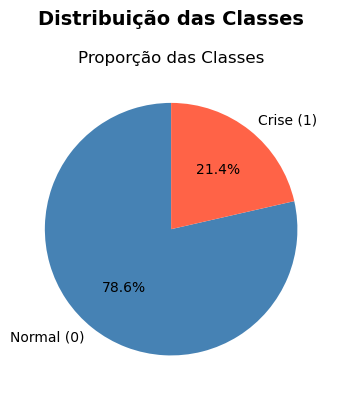

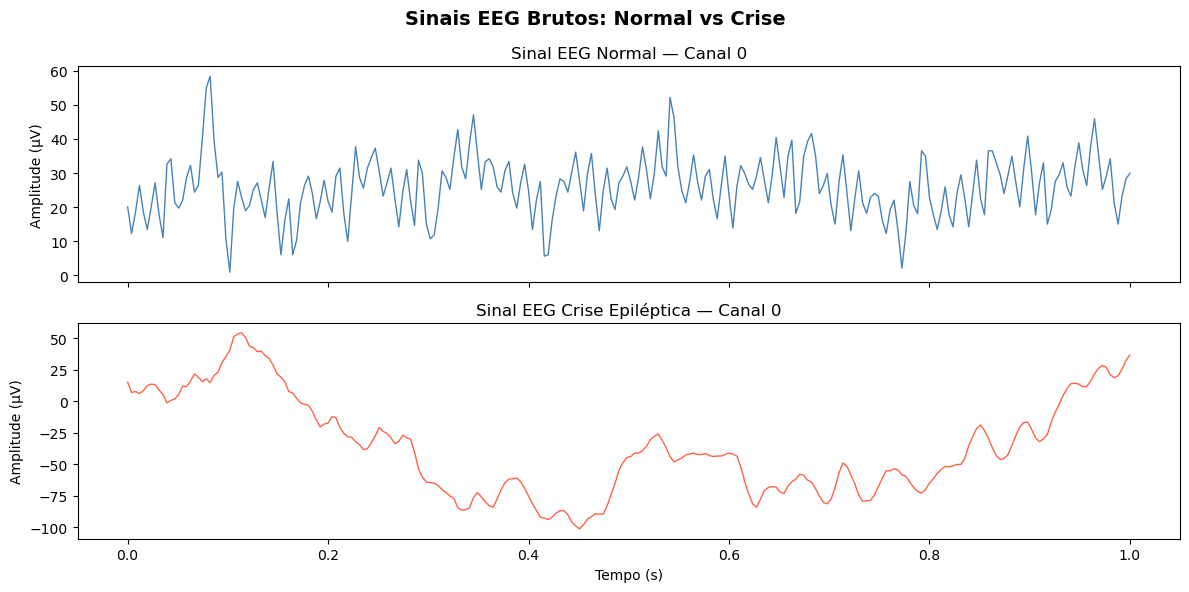

In [5]:
n_crise  = int((y == 1).sum()) # total de segmentos com crise
n_normal = int((y == 0).sum()) # total de segmentos normais
total    = len(y)
print(f'Classe 1 (Crise) : {n_crise} amostras ({100*n_crise/total:.1f}%)')
print(f'Classe 0 (Normal): {n_normal} amostras ({100*n_normal/total:.1f}%)')

# ── Gráfico de distribuição das classes ──────────────────────
# Gráfico de pizza para melhor visualização da distribuição dos dados
fig, ax = plt.subplots(figsize=(11, 4))
ax.pie([n_normal, n_crise], labels=['Normal (0)', 'Crise (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
ax.set_title('Proporção das Classes')
plt.suptitle('Distribuição das Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Visualização dos sinais EEG brutos ───────────────────────
# Pega o primeiro índice de cada classe para comparação visual
idx_normal = np.where(y == 0)[0][0]
idx_crise  = np.where(y == 1)[0][0]

# Eixo de tempo: 256 pontos em 1 segundo = frequência de amostragem 256 Hz
t = np.linspace(0, 1, X.shape[2])
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t, X[idx_normal, 0, :], color='steelblue', linewidth=1)
axes[0].set_title('Sinal EEG Normal — Canal 0')
axes[0].set_ylabel('Amplitude (μV)')
axes[1].plot(t, X[idx_crise,  0, :], color='tomato',    linewidth=1)
axes[1].set_title('Sinal EEG Crise Epiléptica — Canal 0')
axes[1].set_ylabel('Amplitude (μV)')
axes[1].set_xlabel('Tempo (s)')
plt.suptitle('Sinais EEG Brutos: Normal vs Crise', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Balanceamento das Classes

O dataset tem **78% Normal vs 22% Crise**. Sem balancear, o modelo pode atingir
~78% de acurácia simplesmente prevendo sempre 'Normal'. Aplicamos **undersampling**
para igualar as classes na proporção 1:1.

In [6]:
idx1  = np.where(y == 1)[0]   # índices das amostras de crise
idx0  = np.where(y == 0)[0]   # índices das amostras normais
n_min = min(len(idx1), len(idx0))  # tamanho da menor classe

# Sorteia aleatoriamente n_min amostras de cada classe (sem reposição)
idx_bal = np.concatenate([
    np.random.choice(idx1, n_min, replace=False),
    np.random.choice(idx0, n_min, replace=False)
])

# Embaralha para evitar que o modelo veja padrões na ordem dos dados
np.random.shuffle(idx_bal)

X = X[idx_bal]
y = y[idx_bal]

## 5. Pré-processamento
### 5.1 Garantir que `y` fique em vetor

In [7]:
# Garantir que y fique em formato vetorial
y = y.reshape(-1)
print("Shape de y após reshape:", y.shape)

Shape de y após reshape: (16148,)


### 5.2 Extração de Features Estatísticas dos Sinais EEG

Em vez de usar o sinal bruto achatado (flatten), extraímos features estatísticas de cada canal. Isso é necessário porque a diferença entre crises e sinais normais está na **amplitude e variabilidade** do sinal, não nos valores brutos ponto a ponto.

Para cada um dos **23 canais** calculamos **6 features**:

| Feature | O que captura |
|---|---|
| Média | Nível médio do sinal |
| Desvio padrão | Variabilidade geral |
| Valor absoluto médio | Energia média |
| Mínimo | Amplitude mínima |
| Máximo | Amplitude máxima |
| Pico-a-pico | Máximo − Mínimo |

**23 canais × 6 features = 138 features** por amostra.

In [8]:
# Cada operação é calculada no eixo temporal (axis=2), resultando em shape (n, 23) por feature.
# O hstack concatena tudo em (n, 138).
def extrair_features(X):
    # Transforma (n, 23, 256) -> (n,138)
    # 6 features por canal x 23 canais  = 138 features

    media  =      X.mean(axis=2)
    desvio =      X.std(axis=2)
    abs_media =   np.abs(X).mean(axis=2)
    minimo =      X.min(axis=2)
    maximo =      X.max(axis=2)
    pico_a_pico = maximo - minimo # range de sinal 

    return np.hstack([media, desvio, abs_media, minimo, maximo, pico_a_pico])

X = extrair_features(X)
print("Shape de X após extração de features:", X.shape)

Shape de X após extração de features: (16148, 138)


### 5.3 Dividir em treino e teste

In [9]:
# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nShapes após train_test_split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Shapes após train_test_split:
X_train: (12918, 138)
X_test : (3230, 138)
y_train: (12918,)
y_test : (3230,)


### 5.4 Normalizar com Z-score
#### Por que isso é importante?
Sem normalização, algumas variáveis podem ter escalas muito maiores do que outras, deformando a superfície da função objetivo e dificultando a convergência do método iterativo.

In [10]:
# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nShapes após normalização:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Verificação de consistência
assert X_train.shape[0] == y_train.shape[0], "X_train e y_train têm tamanhos incompatíveis"
assert X_test.shape[0] == y_test.shape[0], "X_test e y_test têm tamanhos incompatíveis"

print("\nVerificação concluída: dimensões compatíveis.")


Shapes após normalização:
X_train: (12918, 138)
X_test : (3230, 138)
y_train: (12918,)
y_test : (3230,)

Verificação concluída: dimensões compatíveis.


## 6. Formulação matemática

A regressão logística utiliza a função sigmoide:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

O modelo é definido como:

$$
\hat{y} = \sigma(Xw + b)
$$

A função de custo (Log-Loss) é dada por:

$$
J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$

A atualização dos parâmetros pelo **Gradiente Descendente** é:

$$
w \leftarrow w - \alpha \frac{\partial J}{\partial w}
$$

$$
b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

Para o **Gradiente Descendente Estocástico (SGD)** que em vez de calcular o gradiente sobre todas as $m$ amostras, atualiza os parâmetros usando **uma amostra $i$ por vez**:

$$
\hat{y}^{(i)} = \sigma(\mathbf{w}^T \mathbf{x}^{(i)} + b)
$$

A regra de atualização para cada amostra $i$ é:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot (\hat{y}^{(i)} - y^{(i)}) \cdot \mathbf{x}^{(i)}
$$

$$
b \leftarrow b - \alpha \cdot (\hat{y}^{(i)} - y^{(i)})
$$

## 7. Implementação da regressão logística do zero

In [11]:
def sigmoid(z):
    z = np.clip(z, -500, 500) # np.clip evita overflow no esp() para valores extremos de z
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    eps = 1e-10
    y_hat = np.clip(y_hat, eps, 1 - eps)

    cost = -(1 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return cost

def compute_gradients(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    dw = (1 / m) * (X.T @ (y_hat - y))
    db = (1 / m) * np.sum(y_hat - y)

    return dw, db

# Gradiente Descendente Batch (GD)
# A cada iteração, o gradiente é calculado sobre TODAS as m amostras de treinamento de uma só vez.
# Isso garante convergência suave e determinística em direção ao mínimo global (pois a Log-Loss é convexa).
def gradient_descent_gd(X, y, learning_rate=0.01, epochs=1000, verbose=True):
    n_features = X.shape[1]

    w = np.zeros(n_features)
    b = 0.0
    cost_history = []

    for epoch in range(epochs):
        dw, db = compute_gradients(X, y, w, b)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
            print(f"Época {epoch:4d} | custo = {cost:.6f}")

    return w, b, cost_history

# Gradiente Descendente Estocástico (SGD)
# Minimiza a Log-Loss via Gradiente Descendente Estocástico.
# Diferença do GD batch: em vez de calcular o gradiente sobre todas as amostras, o SGD usa UMA amostra aleatória por atualização.
# A cada época, as amostras são embaralhadas (permutation) para garantir que o modelo não aprenda padrões de ordem nos dados.
def gradient_descent_sgd(X, y, learning_rate=0.001, epochs=50, verbose=True):
    m, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0
    cost_history = []

    for epoch in range(epochs):
        # Embaralha os índices a cada época (fundamental no SGD)
        indices = np.random.permutation(m)
        custos = []
        for i in indices:
            xi = X[i]; yi = y[i]
            yi_hat = sigmoid(xi @ w + b)
            eps = 1e-15
            yi_hat = np.clip(yi_hat, eps, 1 - eps)
            erro = yi_hat - yi

            # Atualização dos parâmetros com o gradiente da amostra i
            w -= learning_rate * erro * xi
            b -= learning_rate * erro

            custos.append(-(yi*np.log(yi_hat) + (1-yi)*np.log(1-yi_hat)))

        # Custo médio da época (média sobre todas as amostras)
        custo_medio = np.mean(custos)
        cost_history.append(custo_medio)

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f'  SGD Época {epoch:4d} | custo médio = {custo_medio:.6f}')
            
    return w, b, cost_history

def predict_proba(X, w, b):
    z = X @ w + b
    return sigmoid(z)

def predict(X, w, b, threshold=0.5):
    probs = predict_proba(X, w, b)
    return (probs >= threshold).astype(int)

## 8. Treinamento do modelo

Rodamos o **GD Batch** (1000 iterações) e o **SGD** (50 épocas) para comparar as curvas de convergência.

In [12]:
# Hiperparâmetros:
#   learning_rate (α): controla o tamanho do passo a cada atualização.
#     - Muito alto → oscila e pode divergir
#     - Muito baixo → converge lentamente
#   epochs: número de iterações/passagens pelo dataset.
#     - Mais épocas → melhor convergência, mas mais tempo de execução

print('Gradiente Descendente Batch (GD)')
w_gd, b_gd, cost_history_gd = gradient_descent_gd(
    X_train,
    y_train,
    learning_rate=0.01,
    epochs=1000,
    verbose=True
)

print('Gradiente Descendente Estocástico (SGD)')
w_sgd, b_sgd, cost_history_sgd = gradient_descent_sgd(
    X_train,
    y_train,
    learning_rate=0.001, # α menor que o GD pois o SGD é mais ruidoso
    epochs=50,
    verbose=True
)

print("\nTreinamento concluído!")

Gradiente Descendente Batch (GD)
Época    0 | custo = 0.672933
Época  100 | custo = 0.584538
Época  200 | custo = 0.563252
Época  300 | custo = 0.549424
Época  400 | custo = 0.539502
Época  500 | custo = 0.531950
Época  600 | custo = 0.525979
Época  700 | custo = 0.521131
Época  800 | custo = 0.517115
Época  900 | custo = 0.513733
Época  999 | custo = 0.510874
Gradiente Descendente Estocástico (SGD)
  SGD Época    0 | custo médio = 0.540480
  SGD Época   10 | custo médio = 0.481595
  SGD Época   20 | custo médio = 0.478812
  SGD Época   30 | custo médio = 0.477005
  SGD Época   40 | custo médio = 0.476970
  SGD Época   49 | custo médio = 0.476423

Treinamento concluído!


## 9. Evolução da função objetivo

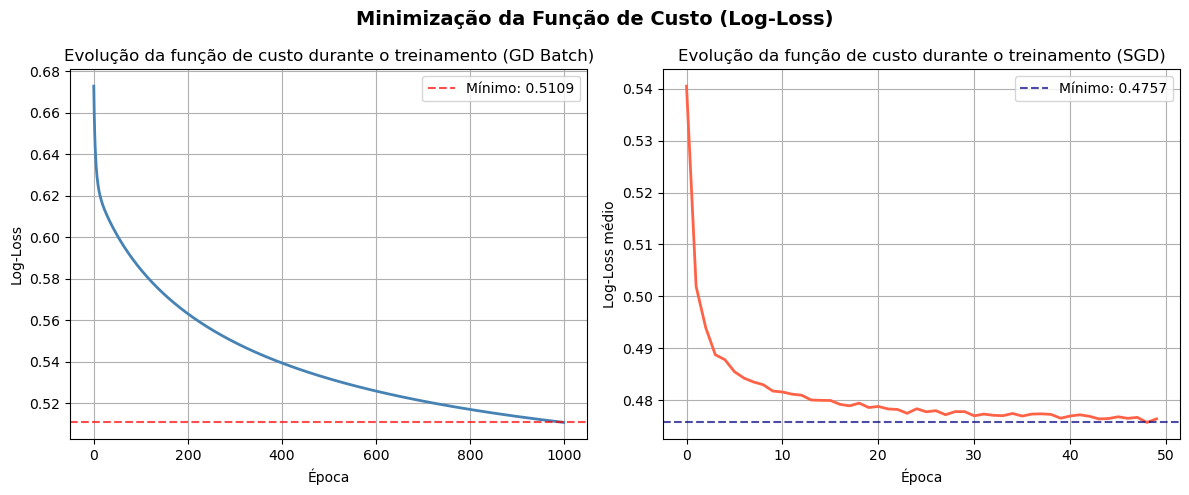

Custo final (GD): 0.510874
Custo final (SGD): 0.476423


In [18]:
# Curvas de convergência da função de custo
# O gráfico mostra como a Log-Loss diminui ao longo do treinamento.
# Uma curva que desce e estabiliza indica convergência (o método encontrou um mínimo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# GD Batch
axes[0].plot(cost_history_gd, color='steelblue', linewidth=2)
axes[0].axhline(
    min(cost_history_gd), color='red', linestyle='--', alpha=0.7,
    label=f'Mínimo: {min(cost_history_gd):.4f}'
)
axes[0].set_title('Evolução da função de custo durante o treinamento (GD Batch)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Log-Loss')
axes[0].legend()
axes[0].grid(True)

# SGD
# O custo aqui é a média por época, ainda assim deve mostrar tendência de queda, mesmo com oscilações entre épocas.
axes[1].plot(cost_history_sgd, color='tomato', linewidth=2)
axes[1].axhline(
    min(cost_history_sgd), color='navy', linestyle='--', alpha=0.7,
    label=f'Mínimo: {min(cost_history_sgd):.4f}'
)
axes[1].set_title('Evolução da função de custo durante o treinamento (SGD)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Log-Loss médio')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Minimização da Função de Custo (Log-Loss)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Custo final (GD): {cost_history_gd[-1]:.6f}')
print(f'Custo final (SGD): {cost_history_sgd[-1]:.6f}')

## 10. Avaliação no conjunto de teste

In [14]:
# Avaliação no conjunto de teste
# Geramos predições para GD e SGD usando os parâmetros otimizados. As métricas são calculadas apenas no conjunto de TESTE

# Predições
y_pred_gd  = predict(X_test, w_gd,  b_gd)
y_prob_gd  = predict_proba(X_test, w_gd,  b_gd)
y_pred_sgd = predict(X_test, w_sgd, b_sgd)
y_prob_sgd = predict_proba(X_test, w_sgd, b_sgd)

def avaliar (nome, y_true, y_pred, y_prob):
    # Exibe um resumo completo das métricas de classificação

    print(f"Acurácia : {accuracy_score (y_true, y_pred):.4f}")
    print(f"Precisão : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score   (y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-score : {f1_score       (y_true, y_pred, zero_division=0):.4f}")
    print(f"AUC-ROC  : {roc_auc_score  (y_true, y_prob):.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=['Normal (0)', 'Crise (1)'],
        digits=4
    ))

print("Resultados no conjunto de teste:")
avaliar('GD Batch (from scratch)', y_test, y_pred_gd,  y_prob_gd)
avaliar('SGD      (from scratch)', y_test, y_pred_sgd, y_prob_sgd)

Resultados no conjunto de teste:
Acurácia : 0.7406
Precisão : 0.8262
Recall   : 0.6093
F1-score : 0.7014
AUC-ROC  : 0.8592
              precision    recall  f1-score   support

  Normal (0)     0.6905    0.8718    0.7707      1615
   Crise (1)     0.8262    0.6093    0.7014      1615

    accuracy                         0.7406      3230
   macro avg     0.7584    0.7406    0.7360      3230
weighted avg     0.7584    0.7406    0.7360      3230

Acurácia : 0.7848
Precisão : 0.8190
Recall   : 0.7313
F1-score : 0.7727
AUC-ROC  : 0.8744
              precision    recall  f1-score   support

  Normal (0)     0.7573    0.8384    0.7958      1615
   Crise (1)     0.8190    0.7313    0.7727      1615

    accuracy                         0.7848      3230
   macro avg     0.7881    0.7848    0.7842      3230
weighted avg     0.7881    0.7848    0.7842      3230



## 11. Visualização da matriz de confusão

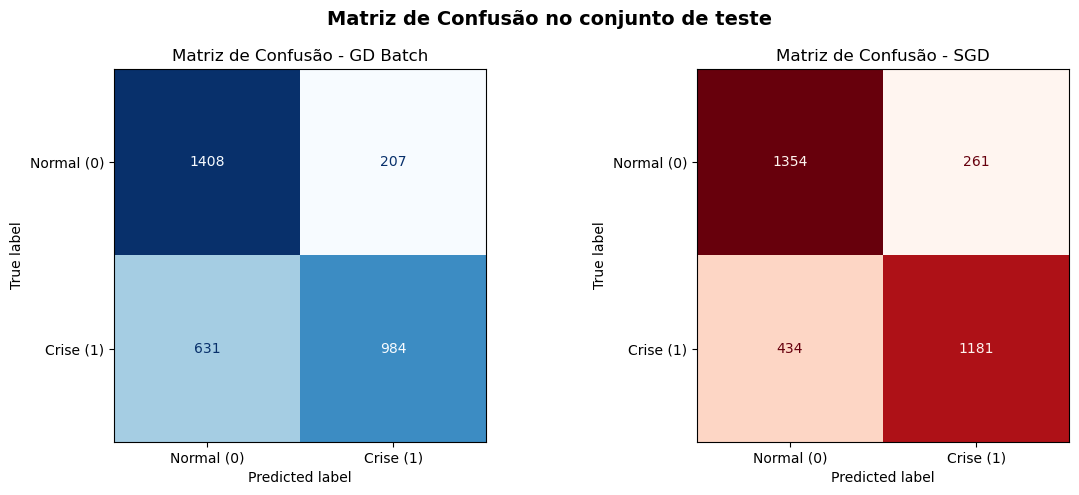

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, y_pred, nome, cor in zip(
    axes,
    [y_pred_gd, y_pred_sgd],
    ['GD Batch', 'SGD'],
    ['Blues', 'Reds']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal (0)', 'Crise (1)']
    ).plot(ax=ax, colorbar=False, cmap=cor)
    ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12)

plt.suptitle('Matriz de Confusão no conjunto de teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.1 Curva ROC

A curva ROC mostra o **trade-off entre detectar crises (TPR) e evitar falsos alarmes (FPR)** para todos os limiares de decisão possíveis. O **AUC** (Área Sob a Curva) resume esse desempenho em um único número (quanto mais próximo de 1.0, melhor).

**Classificação AUC:**

- 1.0 → classificador perfeito
- 0.5 → classificador aleatório (linha tracejada)
- < 0.5 → pior que aleatório

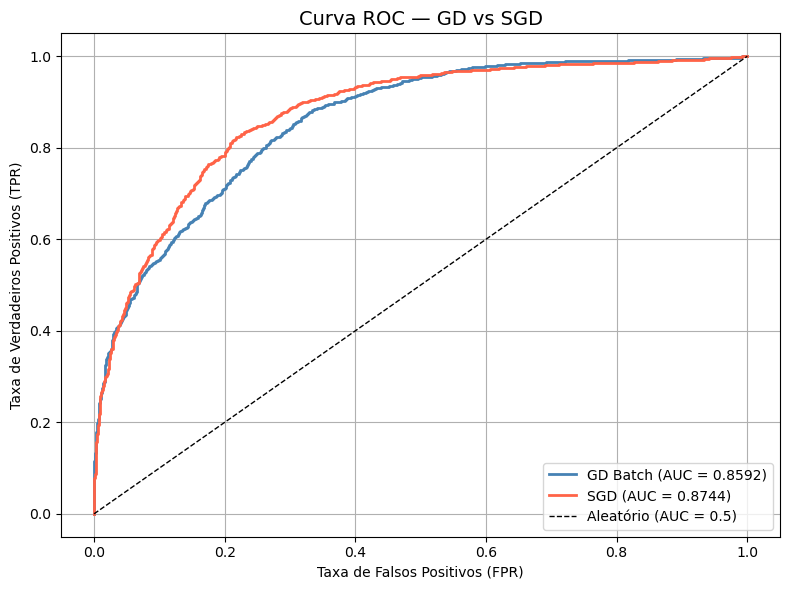

In [16]:
# Curva ROC
# A curva ROC plota TPR (sensibilidade) vs FPR (1 - especificidade) para todos os limiares de decisão possíveis (0 a 1)

plt.figure(figsize=(8, 6))

for y_prob, nome, cor in zip(
    [y_prob_gd, y_prob_sgd],
    ['GD Batch', 'SGD'],
    ['steelblue', 'tomato']
):
    fpr, tpr, _ = roc_curve(y_test, y_prob)    # calcula pontos da curva
    auc = roc_auc_score(y_test, y_prob)        # calcula AUC
    plt.plot(fpr, tpr, color=cor, linewidth=2, label=f'{nome} (AUC = {auc:.4f})')

# Linha de referência: classificador aleatório tem AUC = 0.5
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Aleatório (AUC = 0.5)')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC — GD vs SGD', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 11.2 Comparação com scikit-learn

Para validar a implementação *from scratch*, comparamos com a referência do scikit-learn

In [17]:
# O scikit-learn usa o solver L-BFGS (método quasi-Newton de segunda ordem) — mais sofisticado que o GD de primeira ordem.
# Serve como referência: se nossa implementação manual chega perto dos resultados do sklearn, a implementação está correta.

# Treina o modelo de referência
modelo_sk = LogisticRegression(
    max_iter=1000,       # limite de iterações do solver
    random_state=42,     # reprodutibilidade
    solver='lbfgs'       # método de otimização (quasi-Newton)
)
modelo_sk.fit(X_train, y_train)

y_pred_sk = modelo_sk.predict(X_test)             # rótulos binários
y_prob_sk = modelo_sk.predict_proba(X_test)[:, 1] # probabilidade da classe 1

avaliar('scikit-learn (referência)', y_test, y_pred_sk, y_prob_sk)

#Tabela comparativa final
modelos   = ['GD Batch', 'SGD', 'sklearn']
acuracias = [accuracy_score(y_test, p) for p in [y_pred_gd, y_pred_sgd, y_pred_sk]]
aucs      = [roc_auc_score(y_test, p)  for p in [y_prob_gd, y_prob_sgd, y_prob_sk]]

tabela = pd.DataFrame({'Modelo': modelos, 'Acurácia': acuracias, 'AUC-ROC': aucs})
tabela['Acurácia'] = tabela['Acurácia'].map('{:.4f}'.format)
tabela['AUC-ROC']  = tabela['AUC-ROC'].map('{:.4f}'.format)

print('\n Comparação Final dos Modelos')
print(tabela.to_string(index=False))

Acurácia : 0.7786
Precisão : 0.8196
Recall   : 0.7146
F1-score : 0.7635
AUC-ROC  : 0.8760
              precision    recall  f1-score   support

  Normal (0)     0.7470    0.8427    0.7920      1615
   Crise (1)     0.8196    0.7146    0.7635      1615

    accuracy                         0.7786      3230
   macro avg     0.7833    0.7786    0.7777      3230
weighted avg     0.7833    0.7786    0.7777      3230


 Comparação Final dos Modelos
  Modelo Acurácia AUC-ROC
GD Batch   0.7406  0.8592
     SGD   0.7848  0.8744
 sklearn   0.7786  0.8760


## 12. Discussão dos resultados

Pontos para comentar no relatório:

1. **A função de custo diminuiu ao longo das épocas?**  
   Se sim, isso indica que o Gradiente Descendente está convergindo.

2. **O modelo teve bom desempenho no teste?**  
   Avaliem acurácia, precisão, recall e F1-score.

3. **Houve equilíbrio entre detectar crises e evitar falsos alarmes?**  
   Isso pode ser observado na matriz de confusão.

4. **A normalização ajudou a estabilidade numérica?**  
   Em geral, sim — especialmente em problemas com muitas variáveis.

5. **A implementação manual ficou próxima da solução do `scikit-learn`?**  
   Se sim, isso fortalece a validade da modelagem.

6. **SGD (Gradiente Descendente Estocástico)**
   Compare a convergência do SGD com o GD batch. O SGD oscila mais, mas tende a convergir em menos tempo por ser atualizado amostra a amostra.

## 13. Conclusão

Este projeto modelou a classificação de crises epilépticas por EEG como um problema de **otimização não linear sem restrições**.  
A Regressão Logística foi utilizada como classificador, e o treinamento foi conduzido por **Gradiente Descendente**, minimizando a função **Log-Loss**.

Do ponto de vista de ONL, o ponto central do trabalho é que:

- existe uma função objetivo não linear;
- seu gradiente pode ser calculado explicitamente;
- o problema pode ser resolvido por um método iterativo de primeira ordem;
- o desempenho final pode ser avaliado quantitativamente em dados de teste.

Assim, o notebook cumpre o objetivo de integrar:
- **modelagem matemática**,
- **otimização numérica**,
- **implementação computacional**,
- **análise de resultados**.

## 14. Referências básicas

- Sun, S.; Cao, Z.; Zhu, H.; Zhao, J. *A Survey of Optimization Methods From a Machine Learning Perspective*. IEEE Transactions on Cybernetics, 2019.
- Gambella, C.; Ghaddar, B.; Naoum-Sawaya, J. *Optimization Problems for Machine Learning: A Survey*. European Journal of Operational Research, 2021.
- SILVA, V. M. Aplicação de Apresndizado de Máquina na detecção de convulsões epilépticas em Sinais de EEG. Trabalho de Conclusão de Curso (Sistemas de Informação) — UFU, 2025.
- KURPEL, F. H. Detecção de epilepsia por meio de análise eletroencefalograma utilizando aprendizado de máquina. Trabalho de Conclusão de Curso (Engenharia da Computação) — UTFPR, 2022.
- RAMOS, C. D. Aprendizado de máquina como ferramenta para o prognóstico de pacientes em coma usando sinais eletroencefalográficos. Tese (Doutorado em Engenharia Elétrica) — UFU, 2022.
- SCIKIT-LEARN. API Reference. Disponível em: https://scikit-learn.org/stable/

Dataset:
- BADEA, A.; ADAM, A. CHB-MIT / EEG Seizure Analysis Dataset, 2021. Disponível em: https://www.kaggle.com/adibadea/chbmitseizuredataset.